In [10]:
from typing import TypedDict
from langgraph.graph import StateGraph

In [11]:
class AgentState(TypedDict):
    name:str
    age:int
    final:str
    

In [12]:

def Node1(state:AgentState)->AgentState:
    """This is the first node of the graph """
    state["final"]=f'Hi {state["name"]}'
    return state 

def Node2(state:AgentState)->AgentState:
    """This is the second node of the graph """
    state["final"]=state["final"]+f'.Your age is {state["age"]}'
    return state



In [13]:
graph=StateGraph(AgentState)
graph.add_node("1st_Node",Node1)
graph.set_entry_point("1st_Node")
graph.add_node("2nd_Node",Node2)
graph.add_edge("1st_Node","2nd_Node")
graph.set_finish_point("2nd_Node")

app=graph.compile()



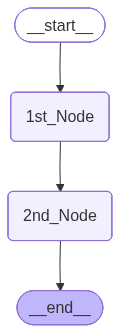

In [14]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [15]:
result=app.invoke({"name":"charlie","age":12})

In [16]:
print(result["final"])

Hi charlie.Your age is 12
